<div style="
background: linear-gradient(135deg, #fceff9, #e3f2fd);
padding:45px;
border-radius:20px;
text-align:center;
border:1px solid #dcdcdc;
box-shadow:0px 4px 12px rgba(0,0,0,0.08);
max-width : 1800px;
margin : auto;
">

<h1 style="color:#5C6BC0; font-size:40px; margin-bottom:10px;">
🌲 Random Forest - Modelo Predictivo
</h1>

<h3 style="color:#8e7cc3; margin-top:0;">
Optimización y Mejora del Modelo de Clasificación
</h3>

<hr style="border: none; height: 2px; background-color: #d1c4e9; margin: 25px 0;">

<p style="font-size:18px; color:#444;">
🌳 <b>Ensamble de Árboles de Decisión</b><br>
⚙️ <b>Ajuste de Hiperparámetros</b><br>
📈 <b>Análisis de Desempeño del Modelo</b><br>
💾 <b>Almacenamiento y Reutilización del Modelo</b>
</p>

<br>

<p style="font-size:14px; color:#888;">
✨ “Muchos árboles trabajan juntos para tomar mejores decisiones.” ✨
</p>

</div>

Prediciendo la diabetes
En el proyecto anterior vimos cómo podíamos utilizar un árbol de decisión para predecir conjuntos de datos relacionados con la clasificación y la regresión. Sin embargo, ¿sabías que podemos mejorar la predicción de un árbol utilizando un random forest?

Como hemos estudiado, un random forest es una agrupación de árboles generados con porciones aleatorias de los datos y con criterios también aleatorios. Esta visión nos permitiría mejorar la efectividad del modelo cuando un árbol individual no es suficiente.

En este proyecto te centrarás en esta idea entrenando el conjunto de datos para mejorar el accuracy.

Recuerda que el proyecto anterior puedes encontrarlo aquí.

Paso 1: Carga del conjunto de datos
Carga el conjunto de datos procesado del proyecto anterior (dividido en muestras de entrenamiento y pruebas y analizado con el EDA).

Paso 2: Construye un random forest
Una forma de optimizar y mejorar los resultados cuando usamos árboles de decisión es generar un random forest con árboles suficientes de tal forma que haya una variedad necesaria que enriquezca la predicción. Entrénalo y analiza sus resultados. Prueba a modificar los dos hiperparámetros que definen al árbol con distintos valores y analiza su impacto con la precisión final y grafica las conclusiones.

Paso 3: Guarda el modelo
Almacena el modelo en la carpeta correspondiente.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder 
from sklearn.tree import plot_tree 
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import joblib

In [3]:
X_train = pd.read_csv("../data/processed/X_train_diabetes.csv")
X_test = pd.read_csv("../data/processed/X_test_diabetes.csv")

y_train = pd.read_csv("../data/processed/y_train_diabetes.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test_diabetes.csv").values.ravel()

In [4]:
X_train.shape

(614, 8)

In [5]:
y_test.shape

(154,)

En esta etapa se cargó el conjunto de datos previamente procesado y dividido en muestras de entrenamiento y prueba, garantizando que el modelo fuera evaluado sobre datos no vistos durante el entrenamiento.

Esta separación permitió evitar sesgos en la evaluación y asegurar una medición objetiva del rendimiento del modelo, manteniendo la integridad del proceso de aprendizaje automático.

In [6]:
rf = RandomForestClassifier(random_state=42)

In [7]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [8]:
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

In [9]:
print("Conjunto Entrenaminto:")
print(confusion_matrix(y_train, y_train_pred))
print(classification_report(y_train, y_train_pred))
train_auc = roc_auc_score(y_train, rf.predict_proba(X_train)[:, 1])
print("AUC Score (Entrenamiento):", train_auc)

Conjunto Entrenaminto:
[[400   0]
 [  0 214]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       400
           1       1.00      1.00      1.00       214

    accuracy                           1.00       614
   macro avg       1.00      1.00      1.00       614
weighted avg       1.00      1.00      1.00       614

AUC Score (Entrenamiento): 1.0


In [10]:
print("\nConjunto Prueba:")
print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))
test_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print("AUC Score (Prueba):", test_auc)


Conjunto Prueba:
[[88 12]
 [22 32]]
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       100
           1       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154

AUC Score (Prueba): 0.8191666666666666


Se implementó el algoritmo Random Forest como una mejora respecto al árbol de decisión individual, aprovechando el aprendizaje conjunto de múltiples árboles para aumentar la precisión y reducir la variabilidad del modelo.

In [11]:
n_trees = [10, 50, 100, 200, 300]
scores = []

for n in n_trees:
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    scores.append(accuracy_score(y_test, pred))

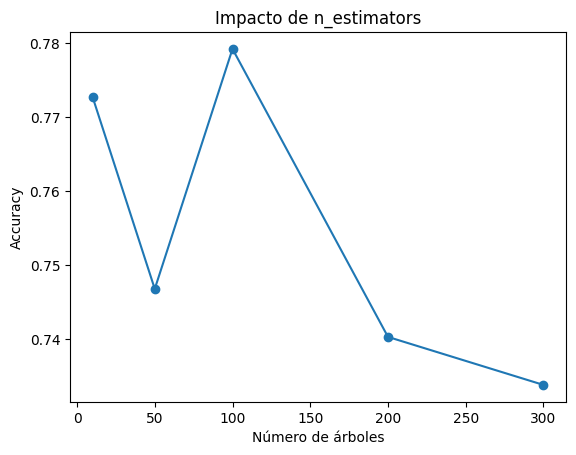

In [12]:
plt.plot(n_trees, scores, marker='o')
plt.xlabel("Número de árboles")
plt.ylabel("Accuracy")
plt.title("Impacto de n_estimators")
plt.show()

La gráfica muestra cómo varía la precisión del modelo Random Forest al modificar el número de árboles utilizados en el entrenamiento. Se observa que inicialmente el rendimiento mejora al aumentar la cantidad de árboles, alcanzando su mejor resultado con 100 árboles.

A partir de este punto, incrementar el número de estimadores no genera mejoras en la precisión e incluso produce una ligera disminución del rendimiento. Esto indica que un número excesivo de árboles puede añadir complejidad innecesaria y mayor costo computacional sin beneficios significativos.

Por lo tanto, 100 estimadores representan el mejor equilibrio entre precisión, estabilidad y eficiencia computacional para este modelo.

In [13]:
depths = [3, 5, 10, 15, None]
scores_depth = []

for d in depths:
    model = RandomForestClassifier(
        max_depth=d,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    scores_depth.append(accuracy_score(y_test, pred))

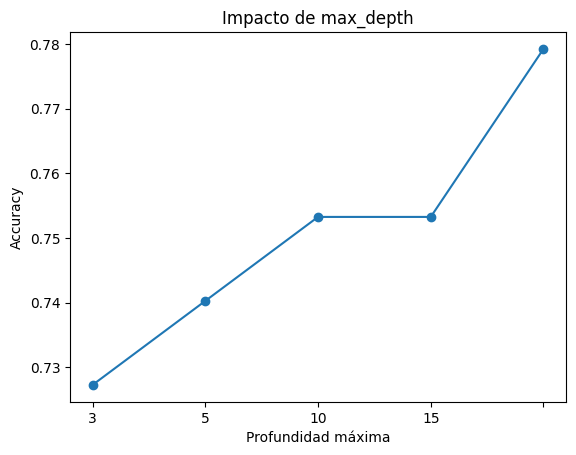

In [14]:
plt.plot(range(len(depths)), scores_depth, marker='o')
plt.xticks(range(len(depths)), depths)
plt.xlabel("Profundidad máxima")
plt.ylabel("Accuracy")
plt.title("Impacto de max_depth")
plt.show()

La gráfica evidencia el efecto de la profundidad máxima de los árboles sobre la precisión del Random Forest. Se observa que profundidades bajas generan menor desempeño debido a que el modelo no logra capturar completamente los patrones presentes en los datos (underfitting).

A medida que aumenta la profundidad, la precisión mejora progresivamente, alcanzando su mejor valor con una profundidad cercana a 20 niveles. Esto indica que árboles más profundos permiten modelar relaciones más complejas sin provocar sobreajuste significativo, gracias al mecanismo de promediado del Random Forest.

En consecuencia, una profundidad máxima de 20 resulta ser la configuración más adecuada para el modelo.

In [15]:
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42
)

In [17]:
rf_final.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [18]:
y_pred = rf_final.predict(X_test)
y_pred

array([1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0])

In [19]:
print("Accuracy final:", accuracy_score(y_test, y_pred))

Accuracy final: 0.7792207792207793


In [25]:
joblib.dump(rf_final, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']

Finalmente, el modelo Random Forest optimizado fue almacenado correctamente utilizando herramientas de serialización, permitiendo su reutilización futura sin necesidad de reentrenamiento.


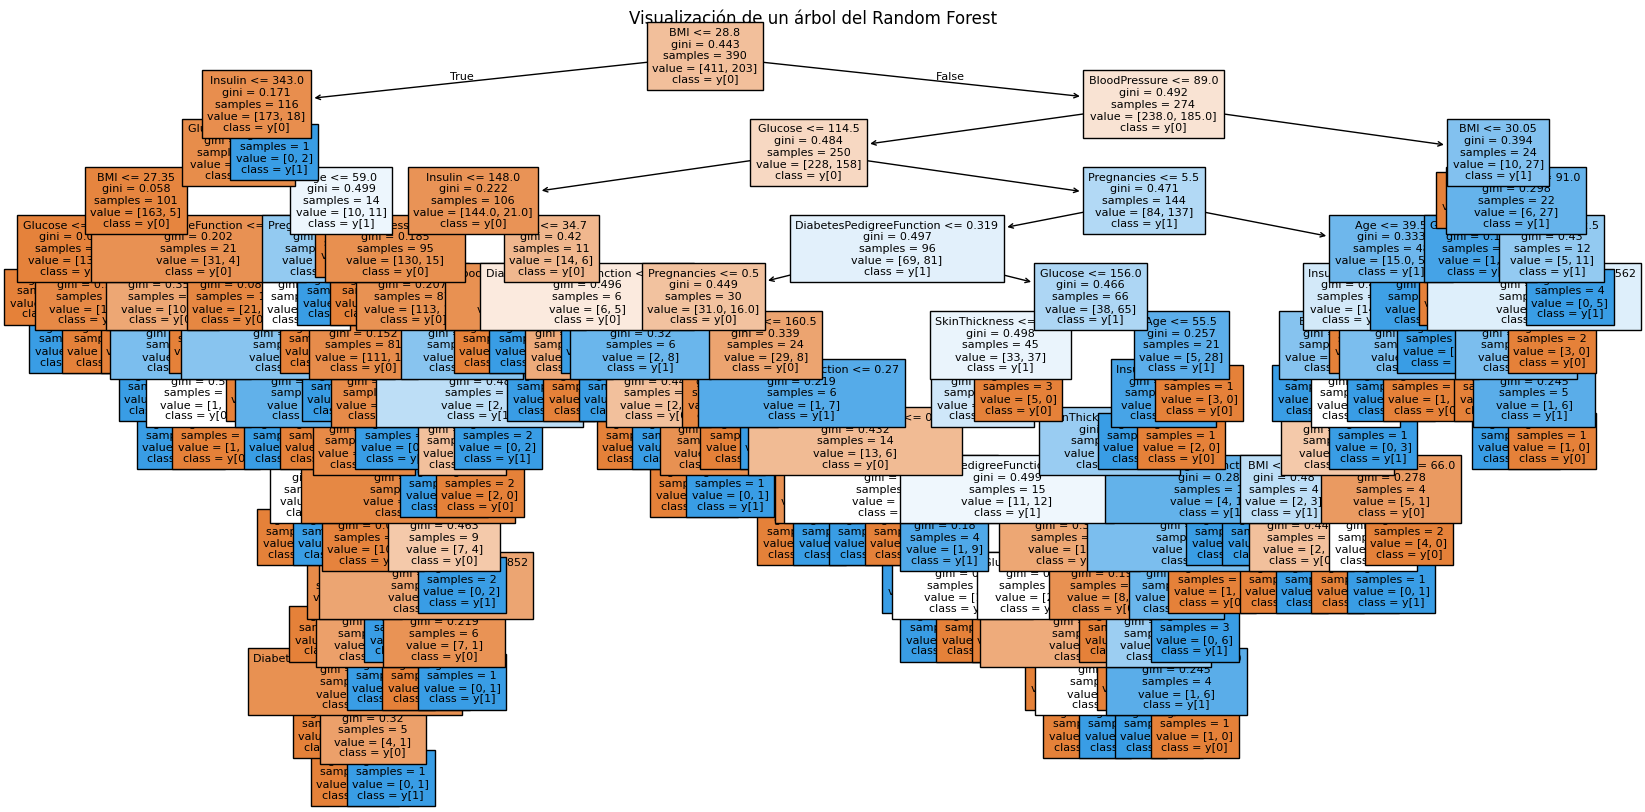

In [21]:
tree = rf_final.estimators_[0]

plt.figure(figsize=(20,10))
plot_tree(
    tree,
    feature_names=X_train.columns,
    class_names=True,
    filled=True,
    fontsize=8
)

plt.title("Visualización de un árbol del Random Forest")
plt.show()

El árbol mostrado corresponde a uno de los múltiples árboles que componen el modelo Random Forest. Se observa que el modelo realiza múltiples divisiones utilizando principalmente variables clínicas como Glucose, BMI, BloodPressure e Insulin, lo que evidencia que el algoritmo aprende patrones complejos a partir de diferentes combinaciones de características.

A diferencia de un árbol de decisión individual, este árbol no representa la decisión final del modelo, sino solo una parte del conjunto. El Random Forest combina las predicciones de muchos árboles, lo que permite reducir el sobreajuste y mejorar la capacidad de generalización del modelo. La profundidad y cantidad de nodos muestran que el modelo captura relaciones no lineales entre las variables para clasificar correctamente la presencia o ausencia de diabetes.

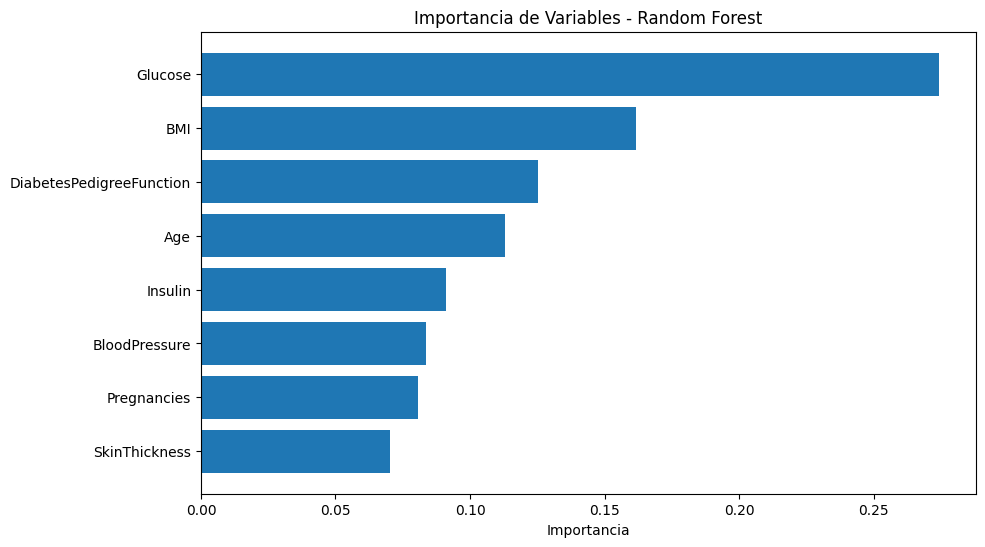

In [22]:
importances = rf_final.feature_importances_

importance_df = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": importances
}).sort_values(by="Importancia", ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df["Variable"], importance_df["Importancia"])
plt.gca().invert_yaxis()
plt.title("Importancia de Variables - Random Forest")
plt.xlabel("Importancia")
plt.show()

El análisis de importancia de variables indica que Glucose es la característica más influyente en la predicción de diabetes, lo cual es coherente desde el punto de vista médico, ya que los niveles de glucosa están directamente relacionados con esta enfermedad.

Variables como BMI, DiabetesPedigreeFunction y Age también presentan una alta relevancia, indicando que factores relacionados con el peso corporal, antecedentes familiares y edad contribuyen significativamente al riesgo de diabetes. En contraste, variables como SkinThickness y Pregnancies tienen menor impacto relativo en la toma de decisiones del modelo.

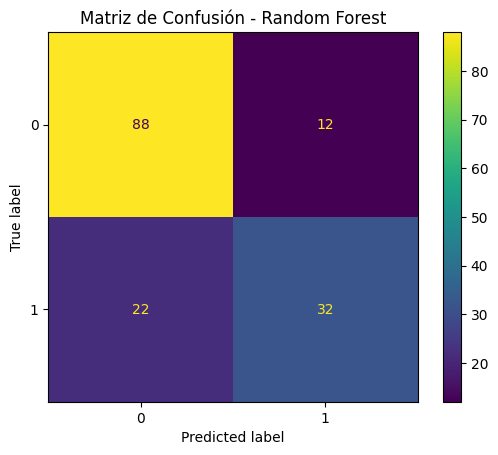

In [24]:
ConfusionMatrixDisplay.from_estimator(
    rf_final,
    X_test,
    y_test
)

plt.title("Matriz de Confusión - Random Forest")
plt.show()

La matriz de confusión muestra que el modelo clasifica correctamente una gran cantidad de casos:

- 88 verdaderos negativos: pacientes sanos correctamente identificados.
- 32 verdaderos positivos: pacientes con diabetes correctamente detectados.
- 12 falsos positivos: pacientes sanos clasificados erróneamente como diabéticos.
- 22 falsos negativos: pacientes con diabetes que el modelo no detectó.

El modelo presenta un buen desempeño general, con una adecuada capacidad para identificar pacientes sin diabetes. Sin embargo, los falsos negativos representan un aspecto crítico, ya que implican casos reales de diabetes que no fueron detectados, lo cual es especialmente importante en aplicaciones médicas.

<div style="
background: linear-gradient(135deg, #fdfbfb, #e3f2fd);
padding:40px;
border-radius:20px;
font-family:Arial, sans-serif;
box-shadow:0px 4px 12px rgba(0,0,0,0.1);
max-width:1800px;
margin:auto;
color:#333;
">

<h2 style="text-align:center; color:#6C9BCF;">
🌲 Conclusión del Modelo Random Forest
</h2>

<p style="font-size:16px; line-height:1.7;">
El presente análisis tuvo como objetivo mejorar el desempeño predictivo del modelo mediante la implementación del algoritmo 
<strong style="color:#7E57C2;">Random Forest</strong>, el cual combina múltiples árboles de decisión para reducir la varianza 
y aumentar la capacidad de generalización.
</p>

<p style="font-size:16px; line-height:1.7;">
A partir del análisis de hiperparámetros, se evaluó el impacto del 
<span style="background-color:#E8F5E9; padding:4px 8px; border-radius:8px;">número de árboles (n_estimators)</span> 
y la 
<span style="background-color:#FFF3E0; padding:4px 8px; border-radius:8px;">profundidad máxima (max_depth)</span>. 
Los resultados mostraron que el mejor rendimiento se obtuvo utilizando 
<strong style="color:#26A69A;">100 árboles</strong> y una 
<strong style="color:#FF8A65;">profundidad máxima de 20</strong>, 
configuración que permitió alcanzar el mayor nivel de precisión sin incrementar innecesariamente la complejidad del modelo.
</p>

<p style="font-size:16px; line-height:1.7;">
En comparación con un árbol de decisión individual, el Random Forest demostró 
<strong style="color:#5C6BC0;">mayor estabilidad</strong> y mejor capacidad para capturar patrones complejos en los datos, 
disminuyendo el riesgo de sobreajuste y mejorando la calidad de las predicciones.
</p>

<p style="font-size:16px; line-height:1.7;">
Finalmente, el modelo optimizado fue almacenado correctamente, permitiendo su reutilización futura para realizar predicciones 
sin necesidad de repetir el proceso de entrenamiento, garantizando así 
<strong style="color:#EF5350;">reproducibilidad y eficiencia</strong>.
</p>

</div>

<div style="
background: linear-gradient(135deg, #fceff9, #e3f2fd);
padding:30px;
border-radius:18px;
text-align:center;
border:1px solid #e0e0e0;
box-shadow:0px 4px 10px rgba(0,0,0,0.08);
margin:20px auto;
max-width:1000px;
">

<h1 style="color:#5C6BC0; font-size:36px; margin-bottom:8px;">
⚖️ Decision Tree vs Random Forest
</h1>

<h3 style="color:#8e7cc3; margin-top:0;">
Comparación de Modelos Predictivos
</h3>

<p style="color:#666; font-size:15px;">
📊 Evaluación de desempeño • 🤖 Selección del mejor modelo
</p>

</div>

In [27]:
decision_tree = joblib.load("../models/decision_tree.pkl")
random_forest = joblib.load("../models/random_forest_model.pkl")

In [28]:
tree_pred = decision_tree.predict(X_test)
rf_pred = random_forest.predict(X_test)

In [30]:
comparison = pd.DataFrame({
    "Modelo": ["Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, tree_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, tree_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, tree_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparison

,Modelo,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.688312,0.636364,0.259259,0.368421
1,Random Forest,0.779221,0.727273,0.592593,0.653061


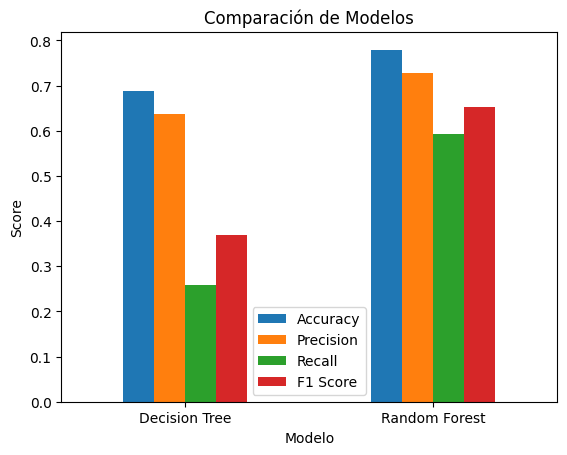

In [31]:
comparison.set_index("Modelo").plot(kind="bar")

plt.title("Comparación de Modelos")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

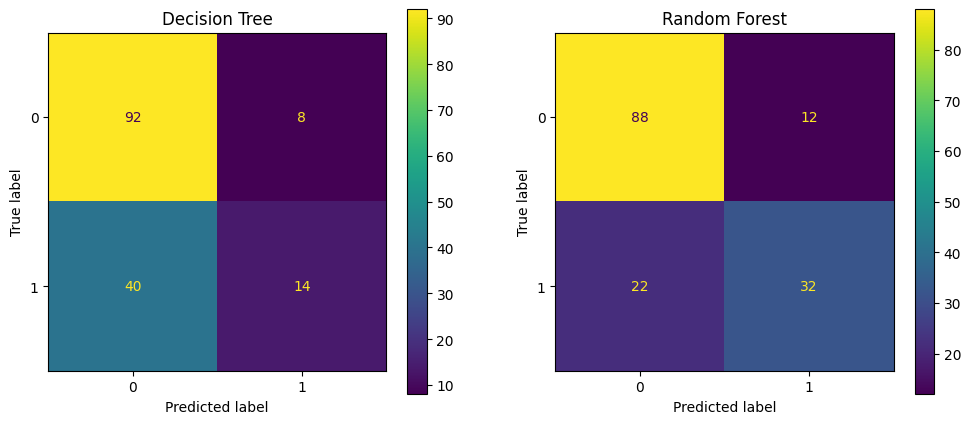

In [32]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

ConfusionMatrixDisplay.from_estimator(
    decision_tree, X_test, y_test, ax=ax[0]
)
ax[0].set_title("Decision Tree")

ConfusionMatrixDisplay.from_estimator(
    random_forest, X_test, y_test, ax=ax[1]
)
ax[1].set_title("Random Forest")

plt.show()

<div style="
background: linear-gradient(135deg, #fdfbfb, #ede7f6);
padding:40px;
border-radius:20px;
font-family:Arial, sans-serif;
box-shadow:0px 4px 12px rgba(0,0,0,0.1);
max-width:1800px;
margin:auto;
color:#333;
">

<h2 style="text-align:center; color:#7E57C2;">
⚖️ Comparación de Modelos: Decision Tree vs Random Forest
</h2>

<p style="font-size:16px; line-height:1.7;">
La comparación entre los modelos 
<strong style="color:#6C9BCF;">Decision Tree</strong> y 
<strong style="color:#26A69A;">Random Forest</strong> evidenció que el Random Forest obtiene mejores resultados en las métricas de evaluación.
</p>

<p style="font-size:16px; line-height:1.7;">
Esto se debe a que combina múltiples árboles de decisión, lo que permite 
<span style="background-color:#E3F2FD; padding:4px 8px; border-radius:8px;">
reducir la varianza del modelo
</span> 
y mejorar significativamente su 
<span style="background-color:#E8F5E9; padding:4px 8px; border-radius:8px;">
capacidad de generalización
</span>.
</p>

<p style="font-size:16px; line-height:1.7;">
Por esta razón, el 
<strong style="color:#5C6BC0;">Random Forest</strong> fue seleccionado como 
<span style="background-color:#FFF3E0; padding:4px 8px; border-radius:8px;">
modelo final del sistema predictivo
</span>, al ofrecer un equilibrio adecuado entre precisión, estabilidad y rendimiento general.
</p>

</div>